In [117]:
import pandas as pd
import numpy as np
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

In [144]:
trash_data = gpd.read_file('./data/trash_hauler_report.csv')
nashville = gpd.read_file('./data/nashville_zip_codes.geojson')
#trash_data

In [6]:
# Finding unique values for the Request column 
pd.unique(trash_data['Request'])

array(['Trash - Backdoor', 'Trash - Curbside/Alley Missed Pickup',
       'Trash Collection Complaint', 'Damage to Property'], dtype=object)

In [7]:
backdoor = trash_data.loc[trash_data['Request'] == 'Trash - Backdoor']
backdoor.shape

(2629, 11)

In [8]:
cs_alley = trash_data.loc[trash_data['Request'] == 'Trash - Curbside/Alley Missed Pickup']
cs_alley.shape

(15028, 11)

In [9]:
complaint = trash_data.loc[trash_data['Request'] == 'Trash Collection Complaint']
#complaint

In [10]:
contains_miss = complaint['Description'].str.contains('miss', case = 'False', na ='False')
#contains_miss

C:\Users\EpicWork\AppData\Local\Temp\ipykernel_24736\3712832755.py:1: FutureWarning: Allowing a non-bool 'na' in obj.str.contains is deprecated and will raise in a future version.
  contains_miss = complaint['Description'].str.contains('miss', case = 'False', na ='False')


In [11]:
miss_complaint = complaint[contains_miss]
miss_complaint.shape

(453, 11)

In [12]:
miss_all = pd.concat([backdoor, cs_alley, miss_complaint], ignore_index = 'True')

In [145]:
miss_all['Short Address'] = miss_all['Incident Address'].str.split(',', n=1).str[0]
miss_all['Short Address'] = miss_all['Short Address'].str.lower()
#miss_all

In [146]:
miss_count_by_address = miss_all['Short Address'].value_counts().reset_index(name='Missed Pickups')
#miss_count_by_address = miss_count_by_address.to_frame()
#miss_count_by_address

In [147]:
frequently_missed = miss_count_by_address.loc[miss_count_by_address['Missed Pickups'] > 1]
#frequently_missed

In [148]:
frequently_missed['Fine Amount'] = (frequently_missed['Missed Pickups'] - 1) * 200
#frequently_missed

C:\Users\EpicWork\AppData\Local\Temp\ipykernel_24736\586745988.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  frequently_missed['Fine Amount'] = (frequently_missed['Missed Pickups'] - 1) * 200


In [17]:
total_damages = frequently_missed['Fine Amount'].sum()
def currency_format(amount):
    return "${:,}".format(amount)
formatted_cost = currency_format(total_damages)
print(f"The total amount in damages is {formatted_cost}")

The total amount in damages is $1,360,000


<h1>Other types of complaints</h1>

In [90]:
other_complaints = trash_data[~trash_data['Request Number'].isin(miss_all['Request Number'])].reset_index()
#other_complaints

<h1>Heat Maps</h1>

<h2>Missed Pick Ups</h2>

In [72]:
miss_by_zip = miss_all['Request Number'].groupby(miss_all['Zip Code']).count().reset_index()
#miss_by_zip

In [46]:
nashville.columns

Index(['OBJECTID', 'ZipCode', 'POName', 'GlobalID', 'geometry'], dtype='object')

In [71]:
miss_map = nashville.merge(miss_by_zip, how = 'left', left_on = 'ZipCode', right_on = 'Zip Code')
#miss_map

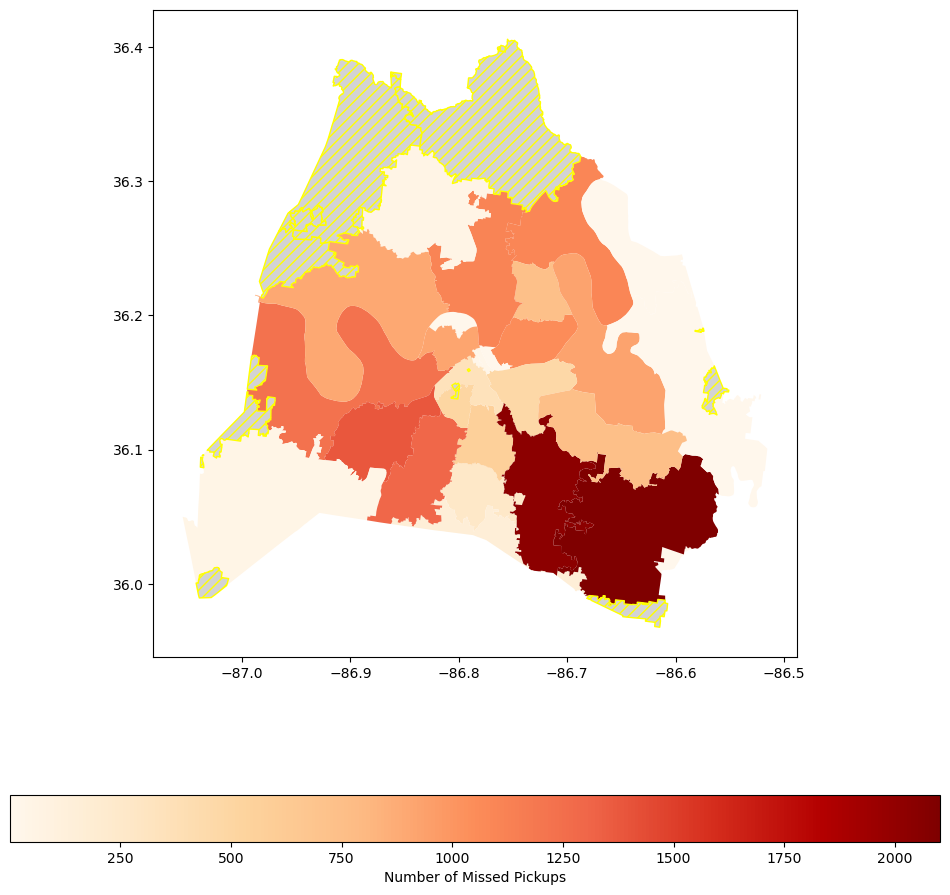

In [136]:
miss_map.plot(column = 'Request Number', 
              cmap = 'OrRd', 
              legend = True, 
              #scheme = "quantiles",
              figsize = (12, 12),
              legend_kwds={"label": "Number of Missed Pickups", "orientation": "horizontal"},
             missing_kwds = {"color": "lightgrey", "edgecolor": "yellow", "hatch": "///"})
fig = plt.gcf()
#fig.set_size_inches(12, 12)
plt.show()
#nashville.plot()

<h2>Total Fines</h2>

In [149]:
fine_by_zip = frequently_missed.merge(miss_all[['Zip Code', 'Short Address']], how = 'left', on = 'Short Address')
fine_by_zip = fine_by_zip.drop_duplicates()
fine_by_zip['Zip Code'].replace('', np.nan, inplace=True)
fine_by_zip.dropna(subset = ['Zip Code'], inplace = True)
fine_by_zip = fine_by_zip.groupby('Zip Code').sum('Fine Amount').reset_index()
#fine_by_zip

C:\Users\EpicWork\AppData\Local\Temp\ipykernel_24736\622137585.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  fine_by_zip['Zip Code'].replace('', np.nan, inplace=True)


In [150]:
fine_map = nashville.merge(fine_by_zip, how = 'left', left_on = 'ZipCode', right_on = 'Zip Code')
#fine_map = fine_map.groupby('ZipCode').sum('Fine Amount').reset_index()
#fine_map

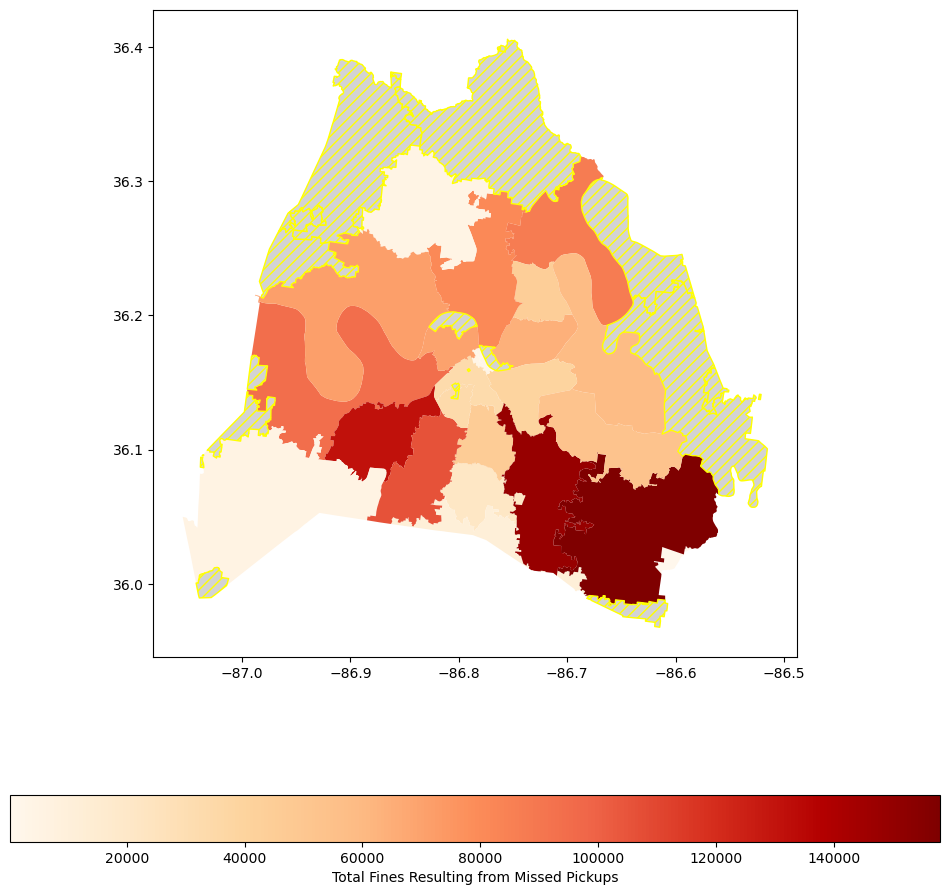

In [138]:
fine_map.plot(column = 'Fine Amount', 
              cmap = 'OrRd', 
              legend = True, 
              #scheme = "quantiles",
              figsize = (12, 12),
              legend_kwds={"label": "Total Fines Resulting from Missed Pickups", "orientation": "horizontal"},
              missing_kwds = {"color": "lightgrey", "edgecolor": "yellow", "hatch": "///"})
fig = plt.gcf()
plt.show()

<h1>Investigating metro crews vs contractor performance</h1>

<h2>Metro Performance</h2>

In [19]:
metro = miss_all.loc[miss_all['Trash Hauler'].str.lower() == 'metro'].reset_index()
#metro

In [20]:
metro_miss_count = metro['Short Address'].value_counts().reset_index(name='Missed Pickups')

In [151]:
metro_freq_miss = metro_miss_count.loc[metro_miss_count['Missed Pickups'] > 1]
metro_freq_miss['Fine Amount'] = (metro_freq_miss['Missed Pickups'] - 1) * 200
#metro_freq_miss

C:\Users\EpicWork\AppData\Local\Temp\ipykernel_24736\3259311114.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metro_freq_miss['Fine Amount'] = (metro_freq_miss['Missed Pickups'] - 1) * 200


In [22]:
metro_damages = metro_freq_miss['Fine Amount'].sum()
metro_format = currency_format(metro_damages)
metro_format

'$215,800'

<h2>Red River Performance</h2>

In [23]:
trash_data['Trash Hauler'].unique()

array(['RED RIVER', 'WASTE IND', 'METRO', '', 'Metro'], dtype=object)

In [24]:
red_river = miss_all.loc[miss_all['Trash Hauler'] == 'RED RIVER'].reset_index()
#red_river

In [25]:
red_river_miss_count = red_river['Short Address'].value_counts().reset_index(name='Missed Pickups')

In [152]:
red_river_freq_miss = red_river_miss_count.loc[red_river_miss_count['Missed Pickups'] > 1]
red_river_freq_miss['Fine Amount'] = (red_river_freq_miss['Missed Pickups'] - 1) * 200
#red_river_freq_miss

C:\Users\EpicWork\AppData\Local\Temp\ipykernel_24736\3247070420.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  red_river_freq_miss['Fine Amount'] = (red_river_freq_miss['Missed Pickups'] - 1) * 200


In [27]:
red_river_damages = red_river_freq_miss['Fine Amount'].sum()
red_river_format = currency_format(red_river_damages)
red_river_format

'$970,000'

<h2>Waste Ind Performance</h2>

In [28]:
waste_ind = miss_all.loc[miss_all['Trash Hauler'] == 'WASTE IND'].reset_index()
#waste_ind

In [29]:
waste_ind_miss_count = waste_ind['Short Address'].value_counts().reset_index(name='Missed Pickups')

In [153]:
waste_ind_freq_miss = waste_ind_miss_count.loc[waste_ind_miss_count['Missed Pickups'] > 1]
waste_ind_freq_miss['Fine Amount'] = (waste_ind_freq_miss['Missed Pickups'] - 1) * 200
#waste_ind_freq_miss

C:\Users\EpicWork\AppData\Local\Temp\ipykernel_24736\3342038832.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  waste_ind_freq_miss['Fine Amount'] = (waste_ind_freq_miss['Missed Pickups'] - 1) * 200


In [31]:
waste_ind_damages = waste_ind_freq_miss['Fine Amount'].sum()
waste_ind_format = currency_format(waste_ind_damages)
waste_ind_format

'$78,200'

<h1>Finding total missed pickups by route</h1>

In [143]:
miss_by_route = miss_all['Request Number'].groupby(miss_all['Trash Route']).count().reset_index()
miss_by_route.sort_values(by = 'Request Number').reset_index()

,index,Trash Route,Request Number
0,23,1502S,1
1,60,2505S,2
2,106,4201S,2
3,78,3303S,2
4,135,4504S,3
...,...,...,...
168,7,1301,264
169,10,1303,268
170,75,3302,300
171,134,4504,329


<h1>Bonus</h1>

For each address, if there are three or more missed pickups within a 180-day period, damages of $1500 will be charged. (A fine will be levied every time three unique missed pickup dates occur within a six-month period for a single address.)

In [156]:
miss_all.columns

Index(['Request Number', 'Date Opened', 'Request', 'Description',
       'Incident Address', 'Zip Code', 'Trash Hauler', 'Trash Route',
       'Council District', 'State Plan X', 'State Plan Y', 'Short Address'],
      dtype='object')